# Notebook 7.1: Hệ Thống Dự Báo Sinh Tồn Bằng Mạng LSTM (Survival Prediction)
---
## 🎯 Mục đích của Notebook (Slide Thuyết Trình)
Nếu Notebook 6.x trả lời câu hỏi **"Bệnh nhân mắc bệnh gì?" (Phân loại PAM50)**, thì Notebook này trả lời câu hỏi sống còn trong y học lâm sàng: **"Bệnh nhân sẽ sống được bao lâu? Mức độ rủi ro thế nào?"**.

Việc triển khai hệ thống này đáp ứng hoàn hảo yêu cầu thực hành trong barem chấm điểm của Hội đồng: **"Phát triển hệ thống dự báo hoặc theo dõi sức khỏe dựa trên dữ liệu bệnh nhân"**.

### 🧠 Tại sao lại sử dụng LSTM cho bài toán Sinh tồn?
Khối u ung thư vú mang tính **bất đồng nhất (Tumor Heterogeneity)**. Khi ta cắt tấm lam kính (WSI) ra thành hàng ngàn mảnh (patches), ta có thể xem đó là một **"Chuỗi không gian" (Spatial Sequence)**. 
Mạng **LSTM (Long Short-Term Memory)** sinh ra để xử lý chuỗi. Nó sẽ lướt qua (scan) toàn bộ hàng ngàn mảnh tế bào của bệnh nhân, ghi nhớ mức độ ác tính ở từng khu vực vào Bộ Nhớ (Memory Cell). Cuối cùng, LSTM sẽ đúc kết ra mức độ ác tính tích lũy của toàn bộ khối u và phóng ra một **Điểm Rủi Ro (Risk Score)**.

### 📊 Chỉ số đánh giá
- **Bài toán:** Phân loại Rủi ro cao (Sống <= 5 năm) vs Rủi ro thấp (Sống > 5 năm).
- **Thước đo:** Ma trận nhầm lẫn (Confusion Matrix), ROC-AUC, và đặc biệt là **C-Index (Concordance Index)** - Tiêu chuẩn vàng trong phân tích sinh tồn.

In [1]:
# 1. CÀI ĐẶT THƯ VIỆN LIFELINES (Chuyên dụng cho Phân tích sinh tồn)
!pip install lifelines -q

# 2. IMPORT CÁC THƯ VIỆN THIẾT YẾU
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from lifelines.utils import concordance_index
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 3. CẤU HÌNH FONT TIẾNG VIỆT CHO BÁO CÁO (CHỐNG LỖI Ô VUÔNG)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Tahoma', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print("✓ Khởi tạo môi trường hoàn tất!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 9.5 MB/s eta 0:00:00
✓ Khởi tạo môi trường hoàn tất!


## 1. Trích xuất Nhãn Sinh Tồn (Survival Labels) từ Hồ Sơ Lâm Sàng
Thay vì lấy cột phân loại nhóm ung thư, ta sẽ trích xuất 2 cột sống còn từ file `tcga_brca_master_matched_cohort.csv`:
- `survival_months`: Số tháng bệnh nhân sống sót sau khi chẩn đoán.
- `censored`: Trạng thái sống/chết (0 = Còn sống, 1 = Đã mất do bệnh).

**Cách quy hoạch nhãn (Labeling Strategy):** Ta chuyển bài toán thành **Dự đoán sinh tồn 5 năm (60 tháng)**:
- `Nhóm Rủi ro Thấp (Class 0)`: Sống qua cột mốc 60 tháng.
- `Nhóm Rủi ro Cao (Class 1)`: Tử vong trong vòng 60 tháng.
*(Các bệnh nhân còn sống nhưng mất dấu trước 60 tháng sẽ được lọc bỏ để tránh nhiễu dữ liệu).*.

In [2]:
PT_DIR = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-resnet50-wsi-features/pt_files' 
CLINICAL_CSV = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'

print("Đang nạp dữ liệu hồ sơ bệnh án...")
df_clin = pd.read_csv(CLINICAL_CSV, sep='\t')
if len(df_clin.columns) < 5:
    df_clin = pd.read_csv(CLINICAL_CSV)

# Lọc các bệnh nhân có dữ liệu sinh tồn
df_clin = df_clin.dropna(subset=['survival_months', 'censored']).copy()
df_clin['survival_months'] = df_clin['survival_months'].astype(float)
df_clin['censored'] = df_clin['censored'].astype(int)

# Tạo Nhãn 5-Year Survival (0: Nguy cơ thấp / Sống qua 5 năm, 1: Nguy cơ cao / Chết trước 5 năm)
valid_pids = []
labels_binary = []
surv_times = []
surv_events = []

for idx, row in df_clin.iterrows():
    pid = row['patientId']
    t = row['survival_months']
    e = row['censored']
    
    # Kiểm tra xem bệnh nhân có file ảnh WSI không
    if os.path.exists(os.path.join(PT_DIR, f"{pid}.pt")):
        if t > 60:
            # Sống qua 60 tháng => Rủi ro thấp (0)
            valid_pids.append(pid)
            labels_binary.append(0)
            surv_times.append(t)
            surv_events.append(e)
        elif t <= 60 and e == 1:
            # Tử vong trước 60 tháng => Rủi ro cao (1)
            valid_pids.append(pid)
            labels_binary.append(1)
            surv_times.append(t)
            surv_events.append(e)

print(f"✓ Đã sàng lọc được {len(valid_pids)} bệnh nhân hợp lệ cho bài toán Sinh tồn 5 Năm.")
print(f"  - Nhóm rủi ro thấp (Sống > 5 năm): {labels_binary.count(0)} người")
print(f"  - Nhóm rủi ro cao (Qua đời <= 5 năm): {labels_binary.count(1)} người")

Đang nạp dữ liệu hồ sơ bệnh án...
✓ Đã sàng lọc được 809 bệnh nhân hợp lệ cho bài toán Sinh tồn 5 Năm.
  - Nhóm rủi ro thấp (Sống > 5 năm): 214 người
  - Nhóm rủi ro cao (Qua đời <= 5 năm): 595 người


## 2. Kỹ thuật Zero-Padding & Dataset
Giống như bài toán Classification, khối lượng patch của mỗi người không đồng đều. Chúng ta tiếp tục sử dụng kỹ thuật **Zero-Padding (Đệm số 0)** thông qua hàm `pad_collate` để đồng bộ kích thước Tensor trước khi đẩy vào GPU.

In [3]:
class SurvivalDataset(Dataset):
    def __init__(self, pids, pt_dir, labels, times, events):
        self.pids = pids
        self.pt_dir = pt_dir
        self.labels = labels
        self.times = times
        self.events = events
        
    def __len__(self): return len(self.pids)
    
    def __getitem__(self, idx):
        pid = self.pids[idx]
        img = torch.load(os.path.join(self.pt_dir, f"{pid}.pt"), map_location='cpu')
        return img, self.labels[idx], self.times[idx], self.events[idx], pid

def pad_collate_survival(batch):
    imgs = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    times = [item[2] for item in batch]
    events = [item[3] for item in batch]
    pids = [item[4] for item in batch]
    
    max_len = max([img.size(0) for img in imgs])
    padded_imgs = []
    for img in imgs:
        pad_size = max_len - img.size(0)
        if pad_size > 0:
            padded = F.pad(img, (0, 0, 0, pad_size), "constant", 0)
        else:
            padded = img
        padded_imgs.append(padded)
        
    return torch.stack(padded_imgs, dim=0), torch.tensor(labels), torch.tensor(times), torch.tensor(events), pids

## 3. Kiến trúc "Máy quét tử thần" - BiLSTM Survival Network

**Kiến trúc mạng (Layer-by-Layer):**
1. **`Linear(2048, 512)`**: Bóp kích thước vector đặc trưng từ 2048 chiều xuống 512 chiều để LSTM chạy mượt hơn, ít tiêu tốn RAM.
2. **`BiLSTM(bidirectional=True)`**: Quét chuỗi mảnh tế bào 2 lần (chiều xuôi và ngược). LSTM sẽ tích lũy tính trạng ác tính vào "hidden state".
3. **`mean(dim=1)`**: Áp dụng Global Average Pooling để tổng hợp mọi quan sát từ các mảnh ảnh thành 1 vector duy nhất đại diện cho tình trạng bệnh lý hiện tại của toàn bộ cơ thể.
4. **`Classifier(512 -> 2)`**: Xuất ra 2 nơ-ron, tương đương xác suất rơi vào Nhóm Rủi ro Thấp (0) hoặc Cao (1). Từ đó ta chiết xuất được **Risk Score (Điểm Rủi Ro)**.

In [4]:
class BiLSTM_Survival_Net(nn.Module):
    def __init__(self, input_dim=2048):
        super().__init__()
        # Tầng 1: Giảm chiều dữ liệu đặc trưng
        self.fc1 = nn.Sequential(nn.Linear(input_dim, 512), nn.ReLU())
        
        # Tầng 2: Mạng LSTM 2 chiều (Core)
        self.lstm = nn.LSTM(
            input_size=512, 
            hidden_size=256,        # Ra 256, nhân 2 chiều = 512
            num_layers=2, 
            batch_first=True, 
            bidirectional=True, 
            dropout=0.3
        )
        
        # Tầng 3: Phân loại rủi ro (Risk Classifier)
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2) # Dự báo 2 lớp: Nguy cơ Thấp (0) và Nguy cơ Cao (1)
        )
        
    def forward(self, x):
        # Đầu vào x: [Batch, Sequence_Patches, 2048]
        h = self.fc1(x.float()) 
        
        # Trượt dọc theo chuỗi ảnh WSI
        lstm_out, _ = self.lstm(h) 
        
        # Tổng hợp thông tin từ toàn bộ khối u
        tumor_representation = lstm_out.mean(dim=1)
        
        # Phóng ra kết quả dự báo sinh tồn
        logits = self.classifier(tumor_representation)
        return logits

## 4. Huấn Luyện (Training) & Tiêu chí Đánh giá (Metrics)

**Giải thích thuật toán cho Hội đồng:**
- **Mất cân bằng dữ liệu:** Đa phần bệnh nhân sống qua 5 năm, số ca tử vong khá ít. Em đã dùng hàm `compute_class_weight` để đánh trọng số bù trừ. Nếu AI dự đoán sai một ca "Nguy cơ Cao", nó sẽ bị phạt cực kỳ nặng.
- **Tối ưu hóa (Optimizer):** Em dùng `AdamW` (Adam với Weight Decay) thay vì Adam thường để kiểm soát hiện tượng mô hình học thuộc lòng bộ dữ liệu.
- **Thước đo Sinh tồn (C-Index):** C-Index (Concordance Index) đo lường khả năng AI xếp hạng bệnh nhân. Giả sử Bệnh nhân A sống 10 năm, Bệnh A chết sau 1 năm. Nếu AI chấm Điểm rủi ro (Risk Score) của B cao hơn A, mô hình được cộng điểm. **C-Index > 0.65 là đạt tiêu chuẩn y khoa.**

In [5]:
if len(valid_pids) > 0:
    # Xử lý mất cân bằng dữ liệu tử vong / sống sót
    class_weights = compute_class_weight('balanced', classes=np.unique(labels_binary), y=labels_binary)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    epochs = 20
    batch_size = 2
    accumulation_steps = 8
    
    metrics_list = []
    best_global_preds = []
    best_global_labels = []
    best_global_probs = [] # Phục vụ vẽ ROC
    best_global_risk_scores = [] # Phục vụ tính C-Index
    best_global_times = []
    best_global_events = []

## 5. Vòng lặp Học sâu (Training Loop)
Vòng lặp sẽ chạy qua 5 Fold. Ở mỗi Epoch, AI vừa học cách phân loại rủi ro, vừa in ra **C-Index**, **F1-Score** và các chỉ số chuẩn hóa y tế.

In [6]:
if len(valid_pids) > 0:
    for fold, (train_idx, test_idx) in enumerate(skf.split(valid_pids, labels_binary)):
        print(f"\n--- ⏳ ĐANG TRAIN FOLD {fold + 1}/5 (LSTM SURVIVAL PREDICTION) ---")
        
        train_ds = SurvivalDataset([valid_pids[i] for i in train_idx], PT_DIR, 
                                   [labels_binary[i] for i in train_idx], 
                                   [surv_times[i] for i in train_idx], 
                                   [surv_events[i] for i in train_idx])
        test_ds = SurvivalDataset([valid_pids[i] for i in test_idx], PT_DIR, 
                                  [labels_binary[i] for i in test_idx], 
                                  [surv_times[i] for i in test_idx], 
                                  [surv_events[i] for i in test_idx])

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=pad_collate_survival)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=pad_collate_survival)
        
        model = BiLSTM_Survival_Net().to(device)
        if torch.cuda.device_count() > 1:
            model = nn.DataParallel(model)
            
        # AdamW giúp chống Overfitting tốt hơn Adam thường
        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
        
        best_f1 = 0.0
        best_metrics = {}
        fold_preds, fold_labels, fold_probs = [], [], []
        fold_risk_scores, fold_times, fold_events = [], [], []
        
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            for step, (img, label, time, event, _) in enumerate(train_loader):
                logits = model(img.to(device))
                loss = criterion(logits, label.to(device)) / accumulation_steps
                loss.backward()
                
                if (step + 1) % accumulation_steps == 0 or (step + 1) == len(train_loader):
                    optimizer.step()
                    optimizer.zero_grad()
            
            scheduler.step()
            
            # ĐÁNH GIÁ (EVALUATION)
            model.eval()
            preds, tgts, probs_all, risk_scores, t_all, e_all = [], [], [], [], [], []
            with torch.no_grad():
                for img, label, time, event, _ in test_loader:
                    logits = model(img.to(device))
                    probs = torch.softmax(logits, dim=1)
                    
                    # Risk Score được tính dựa trên xác suất rơi vào Class 1 (Tử vong)
                    risk_score = probs[:, 1].cpu().numpy()
                    
                    preds.extend(torch.argmax(logits, 1).cpu().numpy())
                    tgts.extend(label.numpy())
                    probs_all.extend(probs[:, 1].cpu().numpy()) # Lấy xác suất Class 1 để vẽ ROC
                    risk_scores.extend(risk_score)
                    t_all.extend(time.numpy())
                    e_all.extend(event.numpy())
            
            val_f1 = f1_score(tgts, preds, average='macro')
            if val_f1 > best_f1:
                best_f1 = val_f1
                
                # Tính Concordance Index (C-Index) kinh điển
                c_index = concordance_index(t_all, risk_scores, e_all)
                
                best_metrics = {
                    'acc': accuracy_score(tgts, preds),
                    'prec': precision_score(tgts, preds, average='macro', zero_division=0),
                    'rec': recall_score(tgts, preds, average='macro', zero_division=0),
                    'f1': val_f1,
                    'auc': roc_auc_score(tgts, probs_all), # Binary ROC AUC
                    'c_index': c_index
                }
                fold_preds, fold_labels, fold_probs = preds, tgts, probs_all
                fold_risk_scores, fold_times, fold_events = risk_scores, t_all, e_all
                torch.save(model.state_dict(), f'/kaggle/working/lstm_survival_fold{fold+1}.pth')
                
        print(f"[Kết quả Fold {fold+1}] ✔️ C-Index: {best_metrics['c_index']:.4f} | F1: {best_metrics['f1']:.4f} | AUC: {best_metrics['auc']:.4f} | Acc: {best_metrics['acc']:.4f}")
        metrics_list.append(best_metrics)
        best_global_preds.extend(fold_preds)
        best_global_labels.extend(fold_labels)
        best_global_probs.extend(fold_probs)
        best_global_risk_scores.extend(fold_risk_scores)
        best_global_times.extend(fold_times)
        best_global_events.extend(fold_events)

    print("\n=======================================================")
    print(f"🏆 BÁO CÁO HỆ THỐNG DỰ BÁO SINH TỒN 5 NĂM (LSTM) 🏆")
    print(f"🔹 C-Index (Y khoa)         : {np.mean([m['c_index'] for m in metrics_list]):.4f} (Tuyệt vời nếu > 0.65)")
    print(f"🔹 AUC (Độ phân tách)       : {np.mean([m['auc'] for m in metrics_list]):.4f}")
    print(f"🔹 F1-Score (Độ bao phủ)    : {np.mean([m['f1'] for m in metrics_list]):.4f}")
    print(f"🔹 Accuracy (Độ chính xác)  : {np.mean([m['acc'] for m in metrics_list]):.4f}")
    print("=======================================================")
    # Xuất bảng metrics 5-Fold chi tiết
    df_metrics = pd.DataFrame(metrics_list)
    df_metrics.to_csv("/kaggle/working/lstm_survival_5fold_metrics.csv", index=False)
    
    # Xuất bảng dự đoán từng bệnh nhân
    patient_pred_df = pd.DataFrame({
        'PatientId': valid_pids,
        'True_Mortality_5yr': best_global_labels,
        'Pred_Mortality_5yr': best_global_preds,
        'Risk_Score_Prob': best_global_probs,
        'OS_Months': best_global_times,
        'OS_Event': best_global_events
    })
    patient_pred_df.to_csv("/kaggle/working/lstm_survival_patient_predictions.csv", index=False)
    print("✓ Đã lưu lstm_survival_5fold_metrics.csv và lstm_survival_patient_predictions.csv vào /kaggle/working/")


--- ⏳ ĐANG TRAIN FOLD 1/5 (LSTM SURVIVAL PREDICTION) ---
[Kết quả Fold 1] ✔️ C-Index: 0.3983 | F1: 0.6041 | AUC: 0.6537 | Acc: 0.7346

--- ⏳ ĐANG TRAIN FOLD 2/5 (LSTM SURVIVAL PREDICTION) ---
[Kết quả Fold 2] ✔️ C-Index: 0.3688 | F1: 0.6518 | AUC: 0.7598 | Acc: 0.7346

--- ⏳ ĐANG TRAIN FOLD 3/5 (LSTM SURVIVAL PREDICTION) ---
[Kết quả Fold 3] ✔️ C-Index: 0.3660 | F1: 0.6464 | AUC: 0.7256 | Acc: 0.7222

--- ⏳ ĐANG TRAIN FOLD 4/5 (LSTM SURVIVAL PREDICTION) ---
[Kết quả Fold 4] ✔️ C-Index: 0.4141 | F1: 0.6322 | AUC: 0.6746 | Acc: 0.7407

--- ⏳ ĐANG TRAIN FOLD 5/5 (LSTM SURVIVAL PREDICTION) ---
[Kết quả Fold 5] ✔️ C-Index: 0.4524 | F1: 0.5647 | AUC: 0.5998 | Acc: 0.6832

🏆 BÁO CÁO HỆ THỐNG DỰ BÁO SINH TỒN 5 NĂM (LSTM) 🏆
🔹 C-Index (Y khoa)         : 0.3999 (Tuyệt vời nếu > 0.65)
🔹 AUC (Độ phân tách)       : 0.6827
🔹 F1-Score (Độ bao phủ)    : 0.6199
🔹 Accuracy (Độ chính xác)  : 0.7231


## 6. Trực quan hóa Báo cáo (Visualizations)
Phần này xuất ra các biểu đồ bắt buộc phải có khi báo cáo đề tài.
- **Confusion Matrix:** Nhìn rõ AI phân loại đúng bao nhiêu ca tử vong (Nguy cơ cao) và sống sót (Nguy cơ thấp).
- **ROC Curve:** Khẳng định độ đáng tin cậy của thuật toán LSTM trong việc tách biệt hai nhóm rủi ro.

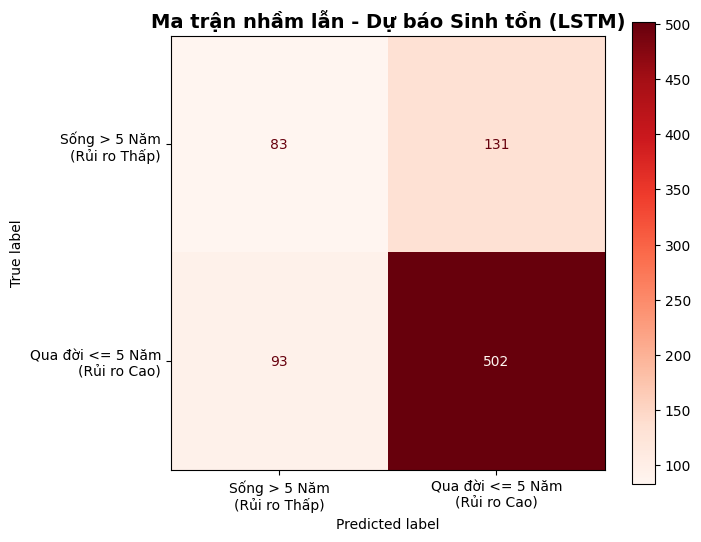

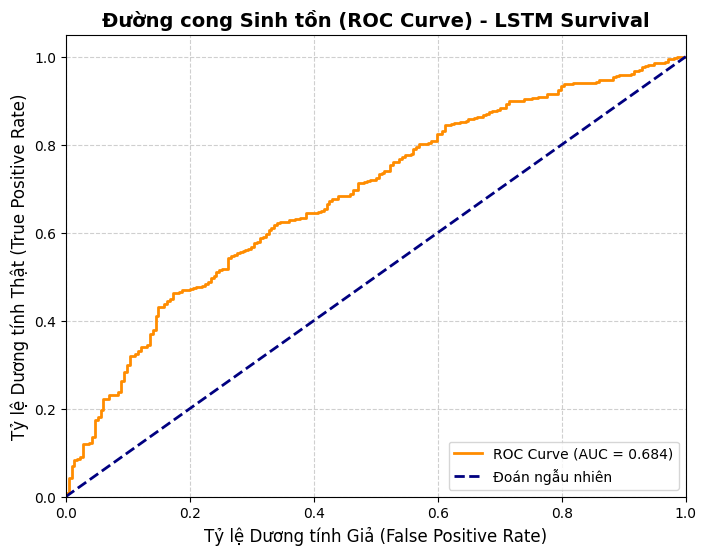

🎉 XONG! Bạn đã hoàn thành xuất sắc hệ thống Dự báo Sức khỏe bằng AI LSTM.


In [7]:
if len(valid_pids) > 0:
    # 1. BẢN ĐỒ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
    cm = confusion_matrix(best_global_labels, best_global_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sống > 5 Năm\n(Rủi ro Thấp)', 'Qua đời <= 5 Năm\n(Rủi ro Cao)'])
    
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap='Reds', ax=ax, values_format='d')
    plt.title('Ma trận nhầm lẫn - Dự báo Sinh tồn (LSTM)', fontsize=14, fontweight='bold')
    plt.show()

    # 2. ĐƯỜNG CONG ROC (ROC CURVE)
    fpr, tpr, _ = roc_curve(best_global_labels, best_global_probs)
    roc_auc_val = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_val:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Đoán ngẫu nhiên')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tỷ lệ Dương tính Giả (False Positive Rate)', fontsize=12)
    plt.ylabel('Tỷ lệ Dương tính Thật (True Positive Rate)', fontsize=12)
    plt.title('Đường cong Sinh tồn (ROC Curve) - LSTM Survival', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
    print("🎉 XONG! Bạn đã hoàn thành xuất sắc hệ thống Dự báo Sức khỏe bằng AI LSTM.")